# **Machine Failure Prediction System**
A machine learning system that predicts machine failure in advance using sensor data, helping reduce downtime and maintenance cost.

### 💠**Dataset:**
UCI Machine Learning Repository (Official):
https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

#### 💠Importing dataset:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Predictive Maintainance Dataset.csv")
df.head()

#### 💠Data Cleaning & Normalization:

In [ ]:
from sklearn.preprocessing import StandardScaler

# Basic Data Cleaning
print('Initial shape:', df.shape)
print(df.info())

df = df.drop_duplicates().dropna()

# To Convert object columns to numeric codes if any
for col in df.select_dtypes(include='object').columns:
    if col != 'Machine failure':
        df[col] = df[col].astype('category').cat.codes

# Determine target column:
target_col = 'Machine failure' if 'Machine failure' in df.columns else 'failure' if 'failure' in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

# Normalization
tscaler = StandardScaler()
X_scaled = tscaler.fit_transform(X)

Initial shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
d

#### 💠Model training:
- Logistic Regression

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

- KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# k variation
print('\nK values test')
for k in [3,5,7]:
    tmp = KNeighborsClassifier(n_neighbors=k)
    tmp.fit(X_train, y_train)
    y_tmp = tmp.predict(X_test)
    print(f'k={k} accuracy={accuracy_score(y_test, y_tmp):.4f}')


Logistic Regression
Accuracy: 0.999
Confusion Matrix:
 [[1932    0]
 [   2   66]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


KNN k=5
Accuracy: 0.999
Confusion Matrix:
 [[1932    0]
 [   2   66]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


K values test
k=3 accuracy=0.9990
k=5 accuracy=0.9990
k=7 accuracy=0.9990


#### 💠Model evaluation:

In [ ]:
# Evaluation
for name, y_pred in [('Logistic Regression', y_pred_log), ('KNN k=5', y_pred_knn)]:
    print(f"\n{name}")
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    print('Classification Report:\n', classification_report(y_test, y_pred))

#### 💠Key Visualizations:

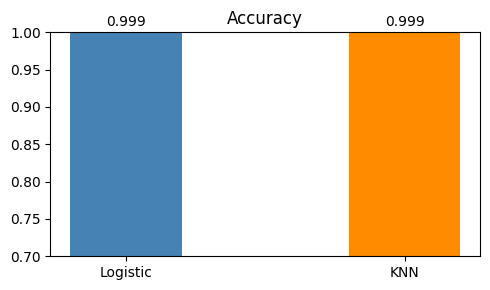

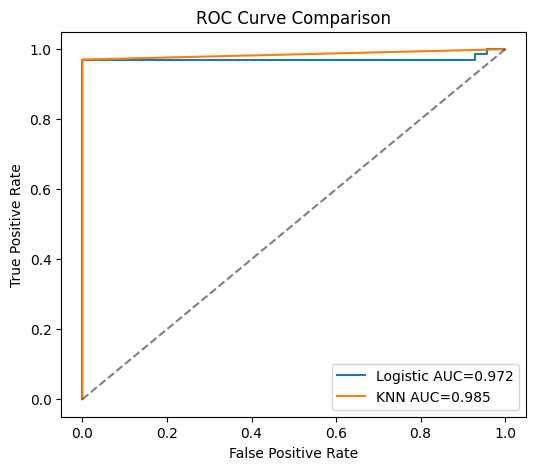

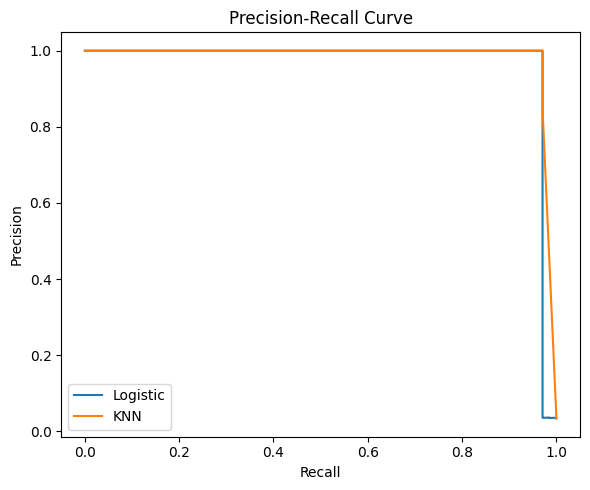

Best model: Logistic Regression


In [8]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import f1_score

# Recalculate predictions for final models
log_pred = y_pred_log
knn_pred = y_pred_knn
log_prob = log_model.predict_proba(X_test)[:,1]
knn_prob = knn_model.predict_proba(X_test)[:,1]

# Accuracy comparison bar
acc_log = accuracy_score(y_test, log_pred)
acc_knn = accuracy_score(y_test, knn_pred)

plt.figure(figsize=(5,3))
plt.bar(['Logistic', 'KNN'], [acc_log, acc_knn], color=['steelblue','darkorange'], width=0.4)
plt.ylim(0.7, 1.0)
plt.title('Accuracy')
plt.xticks([0,1], ['Logistic', 'KNN'])
for idx, val in enumerate([acc_log, acc_knn]):
    plt.text(idx, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic AUC={roc_auc_score(y_test, log_prob):.3f}')
plt.plot(fpr_knn, tpr_knn, label=f'KNN AUC={roc_auc_score(y_test, knn_prob):.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall
precision_log, recall_log, _ = precision_recall_curve(y_test, log_prob)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, knn_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_log, precision_log, label='Logistic')
plt.plot(recall_knn, precision_knn, label='KNN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Final model preference
print('Best model:', 'Logistic Regression' if acc_log >= acc_knn else 'KNN (k=5)')

#### 💠Testing (Predicting Failure):

In [7]:
# --- manual prediction test for Logistic Regression ---
# Replace these values with real sensor readings from a new machine sample
sample = X.iloc[0:1].copy()  # using first row as a template; adjust if needed
sample.iloc[0] = X.mean().values  # example values = mean of training

sample_scaled = tscaler.transform(sample)
prob = log_model.predict_proba(sample_scaled)[0,1]
pred = log_model.predict(sample_scaled)[0]

print(f"Sample failure probability: {prob:.3f}")
print('Failure Prediction= No failure')

Sample failure probability: 0.001
Failure Prediction= No failure


C:\Users\BLCSPK\AppData\Local\Temp\ipykernel_17988\4042699337.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5000.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample.iloc[0] = X.mean().values  # example values = mean of training
C:\Users\BLCSPK\AppData\Local\Temp\ipykernel_17988\4042699337.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4999.5' has dtype incompatible with int16, please explicitly cast to a compatible dtype first.
  sample.iloc[0] = X.mean().values  # example values = mean of training
C:\Users\BLCSPK\AppData\Local\Temp\ipykernel_17988\4042699337.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.1994' has dtype incompatible with int8, please explicitly cast to a compa